In [1]:
import pandas as pd

df= pd.read_csv("ai_student_impact_dataset.csv")

info=df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

ossevare corr votazione, incremento, skill retention e burnout
Major_Category -> più colonne?
Year_of_Study -> diventa int 
Primary_Use_Case -> più colonne?
Prompt_Engineering_Skill -> int
Institutional_Policy -> int


In [2]:
df["GPA_increment"] = df["Post_Semester_GPA"]- df["Pre_Semester_GPA"]

In [3]:
df.value_counts(df["Burnout_Risk_Level"])
trad={"Low":1,"Medium":2,"High":3}
df["Burnout_Risk_Level"]=df["Burnout_Risk_Level"].map(trad)

In [4]:
df[["Burnout_Risk_Level","GPA_increment","Post_Semester_GPA","Skill_Retention_Score"]].corr()

,Burnout_Risk_Level,GPA_increment,Post_Semester_GPA,Skill_Retention_Score
Burnout_Risk_Level,1.000000,-0.006818,-0.095543,-0.058140
GPA_increment,-0.006818,1.000000,0.277146,0.195833
Post_Semester_GPA,-0.095543,0.277146,1.000000,0.169616
Skill_Retention_Score,-0.058140,0.195833,0.169616,1.000000


togliamo ora il target e info su Burnout e Skill Retention

In [5]:
y= df["GPA_increment"].copy()
df.drop(columns=["Burnout_Risk_Level","Post_Semester_GPA","Skill_Retention_Score"], inplace=True)

In [6]:
df.drop(columns="Student_ID",inplace=True)

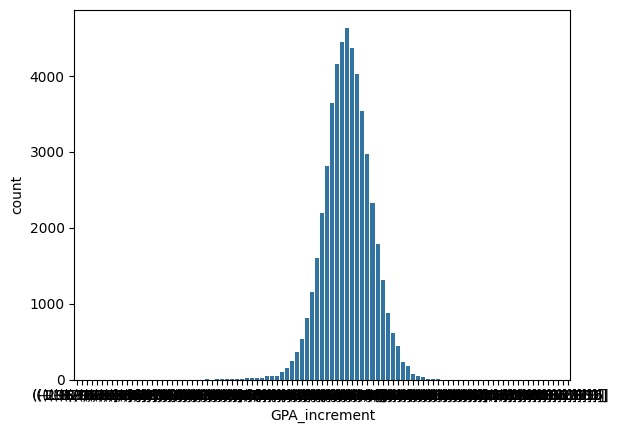

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

gruppi = pd.cut(y, np.linspace(-2,2,100))

sns.countplot(x=gruppi)
plt.show()


In [8]:
df.value_counts(df["Major_Category"])

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

fare modelli diversi per percorsi diversi?

In [9]:
trad={
"Junior": 3 ,
"Freshman" : 1,
"Senior"  : 4, 
"Sophomore"  : 2,
"Graduate" : 5,
}

df["Year_of_Study"]=df["Year_of_Study"].map(trad)

print(df["Year_of_Study"].unique())

[4 3 1 2 5]


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  str    
 1   Year_of_Study               50000 non-null  int64  
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  str    
 5   Prompt_Engineering_Skill    50000 non-null  str    
 6   Tool_Diversity              50000 non-null  int64  
 7   Paid_Subscription           50000 non-null  bool   
 8   Traditional_Study_Hours     50000 non-null  float64
 9   Perceived_AI_Dependency     50000 non-null  int64  
 10  Institutional_Policy        50000 non-null  str    
 11  Anxiety_Level_During_Exams  50000 non-null  int64  
 12  GPA_increment               50000 non-null  float64
dtypes: bool(1), float64(4), int64(4), str(4)
m

In [11]:
for corso in df["Primary_Use_Case"].unique():
    df["is_"+corso]= df["Primary_Use_Case"]==corso

df.drop(columns="Primary_Use_Case",inplace=True)

In [12]:
df.value_counts(df["Prompt_Engineering_Skill"])

Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

In [13]:
trad={
"Beginner": 1 ,
"Intermediate" : 2,
"Advanced"  : 3, 
}

df["Prompt_Engineering_Skill"]=df["Prompt_Engineering_Skill"].map(trad)

print(df["Prompt_Engineering_Skill"].unique())

[1 3 2]


In [14]:

df.value_counts(df["Institutional_Policy"])

Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

In [15]:
for corso in df["Institutional_Policy"].unique():
    df["is_"+corso]= df["Institutional_Policy"]==corso

df.drop(columns="Institutional_Policy",inplace=True)

primo approccio mantenere categorie tutte assieme nello stesso dataset ma in colonne diverse e vediamo (poi dopo proviamo a dividere dataset per fare 5 modelli diversi)

In [16]:
df_by_category = df.copy() #salvo una copia del dataset per poi usarlo dopo per creare modelli separati

In [17]:
for corso in df["Major_Category"].unique():
    df["major_is_"+corso]= df["Major_Category"]==corso

df.drop(columns="Major_Category",inplace=True)

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
df.drop(columns="GPA_increment",inplace=True)
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)

modello baseline

In [19]:
from xgboost import XGBRegressor

rf_model = XGBRegressor(
    n_estimators=100,
    random_state=42
)


rf_model.fit(X_train, y_train) 

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [20]:
predictions = rf_model.predict(X_test)

print(mean_absolute_error(y_test, predictions))

print(r2_score(y_test, predictions))

0.11484872509390091
0.38317568918493494


In [21]:
# un dataframe per ogni categoria
df_dict={
    k:df_by_category[df_by_category["Major_Category"] == k]  for k in df_by_category["Major_Category"].unique()
}


In [22]:
for d in df_dict.values():
    d.drop(columns=["Major_Category"], inplace=True)
d.info()


<class 'pandas.DataFrame'>
Index: 5933 entries, 7 to 49999
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year_of_Study                 5933 non-null   int64  
 1   Pre_Semester_GPA              5933 non-null   float64
 2   Weekly_GenAI_Hours            5933 non-null   float64
 3   Prompt_Engineering_Skill      5933 non-null   int64  
 4   Tool_Diversity                5933 non-null   int64  
 5   Paid_Subscription             5933 non-null   bool   
 6   Traditional_Study_Hours       5933 non-null   float64
 7   Perceived_AI_Dependency       5933 non-null   int64  
 8   Anxiety_Level_During_Exams    5933 non-null   int64  
 9   GPA_increment                 5933 non-null   float64
 10  is_Copywriting/Drafting       5933 non-null   bool   
 11  is_Ideation                   5933 non-null   bool   
 12  is_Summarizing_Reading        5933 non-null   bool   
 13  is_Debugging/Troub

In [ ]:
model_major_dict={}

import optuna

def objective(trial):
    print(f"major {corso}")
    data= df_dict[corso]
    y=data["GPA_increment"]
    X=data.drop(columns='GPA_increment')

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'tree_method': 'hist',
        'enable_categorical':True,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
        'bootstrap_type': "Bayesian",
        
       
        'n_estimators': trial.suggest_int('n_estimators', 50, 250),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3,18),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True)
    }

    if params["bootstrap_type"] == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif params["bootstrap_type"] == "Bernoulli":
        params["subsample"] = trial.suggest_float("subsample", 0.1, 1)

    model = XGBRegressor(**params)

    model.fit(X_train, y_train,verbose=1)

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    return mae


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:

for corso in df_dict.keys():
    
    print(f"major {corso}")
    c=corso

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100, timeout=600)

    print("Number of finished trials: {}".format(len(study.trials)))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))
    

    # model_major_dict[corso]=model

    # business_predictions = model.predict(X_test_business)

    # print("business mae:", mean_absolute_error(y_test_business, business_predictions))
    # print("business r2:", r2_score(y_test_business, business_predictions))





    


[I 2026-06-04 16:25:56,599] A new study created in memory with name: no-name-19e0bbb9-3c71-46f1-8d5f-a81ab3c12c96


major Humanities
major Humanities
       Year_of_Study  Pre_Semester_GPA  Weekly_GenAI_Hours  \
0                  4             2.418               23.31   
16                 2             2.931                2.08   
18                 3             2.975                0.51   
23                 4             3.579                0.45   
24                 1             2.364               28.72   
...              ...               ...                 ...   
49972              4             2.540                8.05   
49985              2             3.661                1.91   
49987              3             2.980                0.50   
49991              1             2.708               13.34   
49994              4             3.556               15.19   

       Prompt_Engineering_Skill  Tool_Diversity  Paid_Subscription  \
0                             1               1               True   
16                            3               3              False   
18         

c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:25:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature", "bootstrap_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-06-04 16:25:57,355] Trial 0 finished with value: 0.12162667219102638 and parameters: {'n_estimators': 152, 'learning_rate': 0.11796209239654183, 'max_depth': 16, 'subsample': 0.9184090381829619, 'colsample_bytree': 0.7761538108111256, 'reg_alpha': 0.0018150810740628085, 'bagging_temperature': 0.5319288639620312}. Best is trial 0 with value: 0.12162667219102638.
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:25:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature", "bootstrap_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-

major Humanities
       Year_of_Study  Pre_Semester_GPA  Weekly_GenAI_Hours  \
0                  4             2.418               23.31   
16                 2             2.931                2.08   
18                 3             2.975                0.51   
23                 4             3.579                0.45   
24                 1             2.364               28.72   
...              ...               ...                 ...   
49972              4             2.540                8.05   
49985              2             3.661                1.91   
49987              3             2.980                0.50   
49991              1             2.708               13.34   
49994              4             3.556               15.19   

       Prompt_Engineering_Skill  Tool_Diversity  Paid_Subscription  \
0                             1               1               True   
16                            3               3              False   
18                          

[I 2026-06-04 16:25:57,702] Trial 3 finished with value: 0.13209294068270652 and parameters: {'n_estimators': 110, 'learning_rate': 0.0017125877500853053, 'max_depth': 14, 'subsample': 0.6558830499770764, 'colsample_bytree': 0.9504878439066823, 'reg_alpha': 0.6676297128996688, 'bagging_temperature': 0.41644678818780756}. Best is trial 2 with value: 0.11405706590076786.
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:25:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature", "bootstrap_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

major Arts
       Year_of_Study  Pre_Semester_GPA  Weekly_GenAI_Hours  \
7                  3             2.746                5.33   
12                 4             3.479                2.86   
25                 4             3.308                2.38   
35                 2             3.632                1.17   
51                 4             2.433               11.16   
...              ...               ...                 ...   
49933              4             3.064                6.66   
49943              4             3.066                2.95   
49963              3             2.970                0.87   
49983              2             3.245                1.42   
49999              2             3.242                3.30   

       Prompt_Engineering_Skill  Tool_Diversity  Paid_Subscription  \
7                             2               3              False   
12                            1               2              False   
25                            3   

[I 2026-06-04 16:27:02,899] Trial 94 finished with value: 0.11756860618902155 and parameters: {'n_estimators': 165, 'learning_rate': 0.043749150446975735, 'max_depth': 4, 'subsample': 0.8554002781335712, 'colsample_bytree': 0.6383926800505001, 'reg_alpha': 0.022935764535140964, 'bagging_temperature': 3.7259183899610138}. Best is trial 82 with value: 0.11712466568761469.
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:27:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature", "bootstrap_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-06-04 16:27:02,978] Trial 95 finished with value: 0.11850632828860092 and parameters: {'n_estimators': 145, 'learning_rate': 0.026815496838149575, 'max_depth': 6, 'subsample': 0.9197194082627365, 'colsample_bytree': 0.7100445080861018, 'reg_alpha': 0.0030762488634748894, 'bagging_temperature': 3.305615862548

major Arts
       Year_of_Study  Pre_Semester_GPA  Weekly_GenAI_Hours  \
7                  3             2.746                5.33   
12                 4             3.479                2.86   
25                 4             3.308                2.38   
35                 2             3.632                1.17   
51                 4             2.433               11.16   
...              ...               ...                 ...   
49933              4             3.064                6.66   
49943              4             3.066                2.95   
49963              3             2.970                0.87   
49983              2             3.245                1.42   
49999              2             3.242                3.30   

       Prompt_Engineering_Skill  Tool_Diversity  Paid_Subscription  \
7                             2               3              False   
12                            1               2              False   
25                            3   

c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:27:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature", "bootstrap_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-06-04 16:27:03,137] Trial 98 finished with value: 0.11676602053613673 and parameters: {'n_estimators': 137, 'learning_rate': 0.05612420431655107, 'max_depth': 4, 'subsample': 0.8791035619200291, 'colsample_bytree': 0.6697601821190687, 'reg_alpha': 0.40893611179265243, 'bagging_temperature': 4.146042723239059}. Best is trial 98 with value: 0.11676602053613673.
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:27:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature", "bootstrap_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-06

major Arts
       Year_of_Study  Pre_Semester_GPA  Weekly_GenAI_Hours  \
7                  3             2.746                5.33   
12                 4             3.479                2.86   
25                 4             3.308                2.38   
35                 2             3.632                1.17   
51                 4             2.433               11.16   
...              ...               ...                 ...   
49933              4             3.064                6.66   
49943              4             3.066                2.95   
49963              3             2.970                0.87   
49983              2             3.245                1.42   
49999              2             3.242                3.30   

       Prompt_Engineering_Skill  Tool_Diversity  Paid_Subscription  \
7                             2               3              False   
12                            1               2              False   
25                            3   